# Phase 2 Final Mass Analysis

This notebook analyzes the effects of treatments on the final tissue mass, shell mass, and T:S ratio of experimental oysters. Growth analysis is in a separate notebook. 

### load packages, read in data, etc.

In [2]:
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

In [3]:
getwd()
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC")

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC"

In [4]:
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum"  "contr.poly"

In [5]:
Growth_Data_forR <- read_csv("Oyster_Weight_Data/growth_phase2.1_weightsSKM.csv", 
                             col_types = cols(Phase_1_temp = col_factor(), 
                                              Phase_1_DO =col_factor(), 
                                              Phase_2.1_temp =col_factor(), 
                                              Phase_2.1_DO=col_factor(), 
                                              Phase_1_rep =col_factor(), 
                                              Phase_2_rep =col_factor(),
                                              Ratio_tissue_shell_mg = col_double(),
                                              Phase1_Phase2_rep = col_factor(),
                                              Phase_1_treat = col_factor(),
                                              Phase_2_treat = col_factor(),
                                              Phase_2_rep_R = col_factor(),
                                              Phase_1_rep_R = col_factor()))

### Filter to exclude dead oysters

In [6]:
Growth_Data_forR_full <- Growth_Data_forR %>%
  filter(Exclude_all != "Y" | is.na(Exclude_all)) %>%
  mutate(prop_tissue_growth = Actual_tissue_growth_mg / Actual_tissue_pre_mg,
    prop_shell_growth = Actual_shell_growth_mg / Actual_shell_pre_mg, 
    tissuegrowthratio = Actual_tissue_post_mg/Actual_tissue_pre_mg,
    shellgrowthratio = Actual_shell_post_mg/Actual_shell_pre_mg,
    log_shell_growth_mg = log(Actual_shell_growth_mg),
    whole_growth_mg = Dry_weight_post - Dry_weight_pre,
    meat_yield_post = Actual_tissue_post_mg/Dry_weight_post,
    shell_yield_post = Actual_shell_post_mg/Dry_weight_post)

# 1. Effect of phase 2, TISSUE

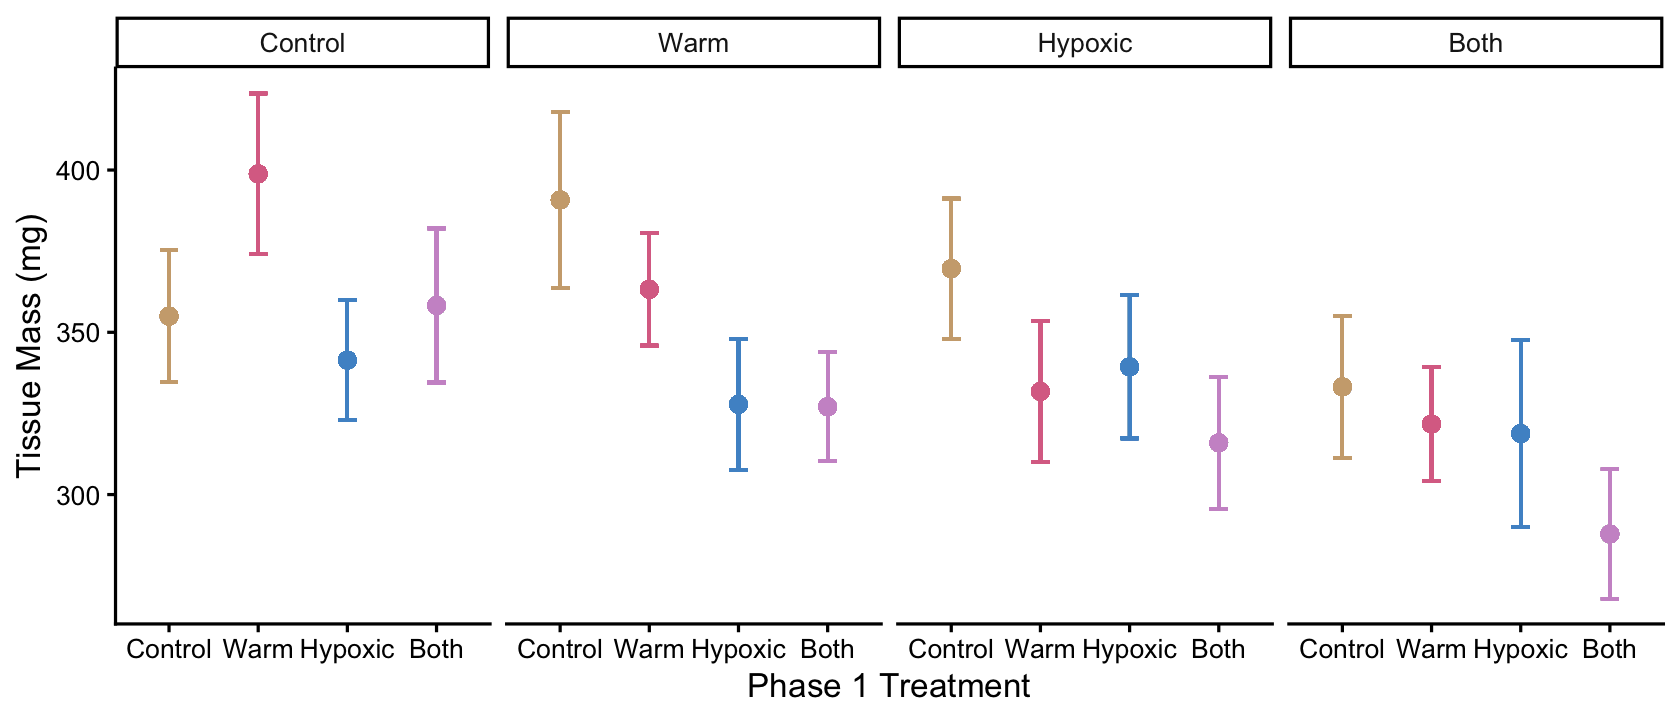

In [9]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE
summary_stats_t <- Growth_Data_forR_full %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_post = mean(Actual_tissue_post_mg, na.rm = TRUE),
    se_post = std.error(Actual_tissue_post_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_post, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_post - se_post, ymax = mean_post + se_post), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs( x = "Phase 1 Treatment", y = "Tissue Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

## statistical analysis

In [29]:
#log transformed
m1_post <- lmer(log(Actual_tissue_post_mg)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Growth_Data_forR_full, REML=TRUE)

boundary (singular) fit: see help('isSingular')



In [30]:
aov_tab <- Anova(m1_post, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.488928e+04,1,23.74589,0.0000
Phase_1_DO,6.288544e+00,1,16.54189,0.0229
Phase_1_temp,1.018014e-01,1,16.54068,0.7537
Phase_2.1_temp,3.448836e-01,1,20.00036,0.5636
Phase_2.1_DO,1.479479e+00,1,20.00080,0.2380
Phase_1_DO:Phase_1_temp,1.629089e-02,1,16.54502,0.9000
Phase_1_DO:Phase_2.1_temp,6.091865e-01,1,19.99671,0.4442
Phase_1_temp:Phase_2.1_temp,7.550090e-02,1,19.98271,0.7863
Phase_1_DO:Phase_2.1_DO,9.734659e-05,1,20.00162,0.9922


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.6144303,0.8650683
,1101,NA,NA


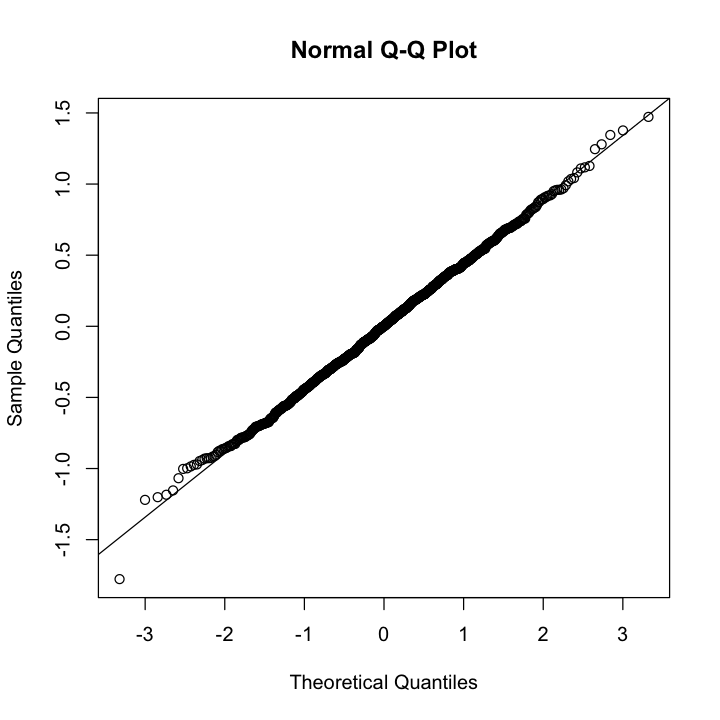

In [31]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

leveneTest(log(Actual_tissue_post_mg)~Phase_1_treat*Phase_2_treat, Growth_Data_forR_full) 
m1.e <- residuals(m1_post) 
qqnorm(m1.e)
qqline(m1.e)

passes diagnostics

In [32]:
#posthocs
emmeans(m1_post,specs = pairwise ~ Phase_1_DO, adjust = "none")
emmeans(m1_post,specs = pairwise ~ Phase_1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean     SE   df lower.CL upper.CL
 Hyp          5.66 0.0510 29.5     5.56     5.77
 Norm         5.76 0.0509 29.4     5.66     5.87

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast   estimate     SE   df t.ratio p.value
 Hyp - Norm   -0.101 0.0402 16.5  -2.508  0.0229

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 


NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Warm         Hyp            5.63 0.0690 27.8     5.48     5.77
 Ambient      Hyp            5.69 0.0689 27.6     5.55     5.83
 Warm         Norm           5.79 0.0690 27.8     5.64     5.93
 Ambient      Norm           5.75 0.0687 27.4     5.61     5.89

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast                   estimate     SE   df t.ratio p.value
 Warm Hyp - Ambient Hyp      -0.0642 0.0486 23.3  -1.321  0.1994
 Warm Hyp - Warm Norm        -0.1593 0.0930 23.8  -1.714  0.0995
 Warm Hyp - Ambient Norm     -0.1208 0.0974 27.6  -1.240  0.2254
 Ambient Hyp - Warm Norm     -0.0951 0.0975 27.7  -0.976  0.3377
 Ambient Hyp - Ambient Norm  -0.0566 0.0926 23.5  -0.611  0.5469
 Warm Norm - Ambient Norm     0.0385 0.0484 23.0   0.795  0.4345

Result

### plotting significant interactions

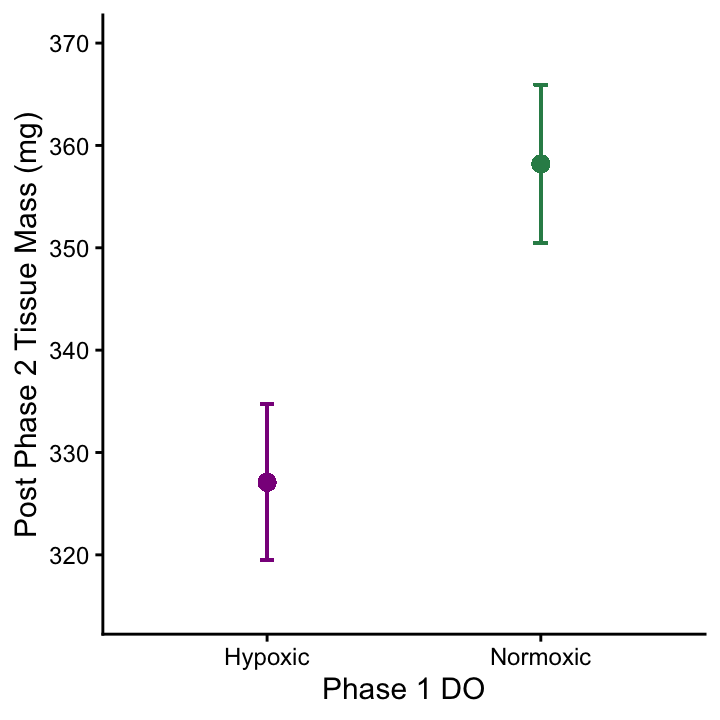

In [39]:
stats_t <- Growth_Data_forR_full %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_post = mean(Actual_tissue_post_mg, na.rm = TRUE),
    se_post = std.error(Actual_tissue_post_mg, na.rm = TRUE))
#reorder
stats_t$Phase_2.1_DO <- factor(stats_t$Phase_2.1_DO, 
                               levels = c("Norm","Hyp"))
#Tissue plot with mean and SD
ggplot(stats_t, aes(x = Phase_1_DO, y = mean_post, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_post - se_post, ymax = mean_post + se_post), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  labs(x = "Phase 1 DO", y = "Post Phase 2 Tissue Mass (mg)") +
ylim(315, 370)+
  theme(legend.position = "none") # Remove legend

### Regardless of phase 2 treatment, oysters were smaller when they experienced early life hypoxia (p = 0.023)

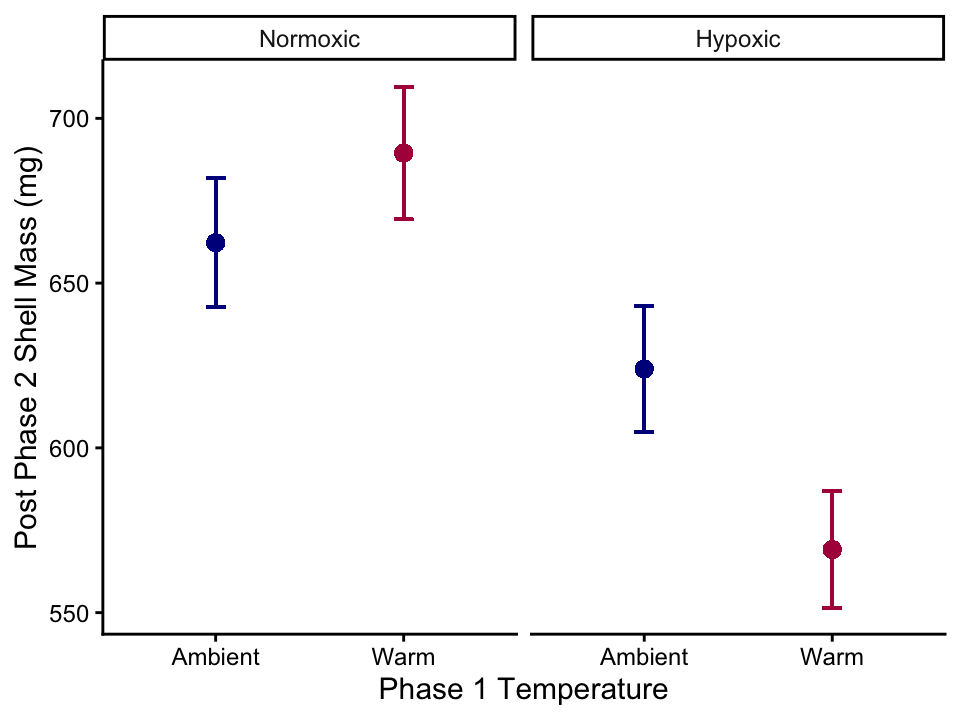

In [40]:
#format display for jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

#shell growth and Phase_1_temp:Phase_2.1_DO
stats_s <- Growth_Data_forR_full %>%
  group_by(Phase_1_temp, Phase_2.1_DO) %>%
  mutate(
    mean_post = mean(Actual_shell_post_mg, na.rm = TRUE),
    se_post = std.error(Actual_shell_post_mg, na.rm = TRUE))

#reorder Phase_1_temp:Phase_2.1_DO
stats_s$Phase_1_temp <- factor(stats_s$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
stats_s$Phase_2.1_DO <- factor(stats_s$Phase_2.1_DO, 
                                        levels = c("Norm","Hyp"))

#plot with mean and SD, SHELL
ggplot(stats_s, aes(x = Phase_1_temp, y = mean_post, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_post - se_post, ymax = mean_post + se_post), 
                width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2.1_DO), labeller = as_labeller(c("Norm" = "Normoxic", "Hyp" = "Hypoxic")),
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Post Phase 2 Shell Mass (mg)") +
  scale_x_discrete(labels = c("Norm" = "Normoxic", "Hyp" = "Hypoxic")) +
  theme(legend.position = "none") # Remove legend

### When exposed to early life warming, oysters were larger in phase 2 normoxia than hypoxia (p = 0.07)

In [ ]:
#Warm Hyp - Warm Norm  p = 0.0995